# Prepare & Sample Gold Standard Dataset

## Prerequisites

In [1]:
%pip install matplotlib pandas presidio_analyzer presidio_anonymizer nltk faker


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import re

In [3]:
RANDOM_STATE = 42

## Set up taxonomy regex - query Athena

In [4]:
# Using (?i) for case-insensitivity. 
# Using \\b for word boundaries (so 'asb' doesn't match 'wasburn')

category_regex_dict = {
    # 1. Safety & Risk
    # Includes: Domestic abuse, Fire, Exploitation, Gangs, ASB, Child risk, Criminal, Violence, Gas Capped, Medically unsuitable
    "cat_safety_risk": r"(domestic\s+(abuse|violence)|fire\s+(risk|hazard|safety)|exploit(?:ation|ed)|cuckooing|gang(?:s)?\b|\basb\b|anti[-\s]?social|child(?:ren)?\s+at\s+risk|criminal|violenc[e]|violent|gas\s+capped|unsuitable\s+(home|property))",

    # 2. Mobility
    # Includes: Physical disability, Temporary mobility, General mobility issues
    "cat_mobility": r"(mobility|wheelchair|walking\s+(stick|frame)|crutches|bedbound|housebound|paralys(?:ed|zed)|physical(?:ly)?\s+(?:disab|impair)|amputee)",

    # 3. Life Events
    # Includes: Identity, Refugee, Veteran, Trauma, Bereavement, Children removed, Institution, Rehousing, Prison, Homelessness
    "cat_life_events": r"(transgender|non[- ]binary|refugee|asylum\s+seeker|veteran|armed\s+forces|trauma|bereave(?:ment|d)|pass(?:ed)?\s+away|\bdied\b|children\s+removed|decant|rehous|prison|jail|homeless|sleeping\s+rough|temporary\s+accommodation)",

    # 4. Housing Conditions
    # Includes: Basic needs, Disrepair, Infestation, Dangerous animals, Self-neglect, Damp/Mould, Overcrowding
    "cat_housing_conditions": r"(disrepair|infest(?:ation|ed)|mice|rats|cockroaches|bed\s+bugs|dangerous\s+(dog|animal)|self[-\s]?neglect|hoard(?:ing|er)|damp|mou?ld|overcrowd(?:ing|ed)|no\s+(heating|water|electricity|gas))",

    # 5. Health
    # Includes: Terminal, Care setting (medical), Mental capacity, Neurodiversity, Cognitive, Reproductive, Young children, Respiratory, Mental Health, Isolation, Poor health, EHCP
    "cat_health": r"(terminal(?:ly)?|end\s+of\s+life|mental\s+capacity|autis(?:m|tic)|adhd|learning\s+disab|dementia|alzheimer|cognitiv|pregnan|maternity|asthma|copd|respiratory|breath(?:ing)?|mental\s+health|depression|anxiety|suicid|isolat(?:ed|ion)|ehcp|poor\s+health)",

    # 6. Financial
    # Includes: Income status, Cost of living, Financial affairs/team
    "cat_financial": r"(financial\s+(?:hardship|difficult)|\barrears\b|\bdebt\b|food\s+bank|cost\s+of\s+living|universal\s+credit|\buc\b|benefits|income\s+support)",

    # 7. Disability (Sensory Focus)
    # Includes: Hearing, Visual, Speech impairments
    "cat_disability": r"(\bblind\b|\bdeaf\b|visually\s+impaired|hearing\s+impaired|hard\s+of\s+hearing|sensory)",

    # 8. Communication Needs
    # Includes: Digital exclusion, Language/Literacy barriers
    "cat_communication": r"(digital(?:ly)?\s+exclu|no\s+internet|no\s+smartphone|interpreter|translat(?:or|ion)|illiterat|cannot\s+read|language\s+barrier|esol)",

    # 9. Care
    # Includes: Care leaver/experienced, Looked after, Social care client, Caring responsibility
    "cat_care": r"(care\s+leaver|care\s+experienced|looked\s+after\s+child|\blac\b|social\s+(?:care|worker)|carer|caring\s+responsibilit|nursing\s+home|care\s+home)",

    # 10. Addiction
    # Includes: Gambling, Substance misuse
    "cat_addiction": r"(gambling|betting|substance\s+(?:misuse|abuse)|\bdrug\b|\balcohol\b|addict(?:ion|ed))",

    # 11. Adaptation
    # Includes: Requires adapted property, specific adaptations
    "cat_adaptation": r"(adapt(?:ed|ation)|wet\s+room|stairlift|ramp|hoist|grab\s+rail(?:s)?)"
}

In [5]:
select_lines = [
    "n.*"
]

# Loop through our new 11 categories
for category, pattern in category_regex_dict.items():
    # Athena needs backslashes safely escaped in the SQL string
    athena_safe_pattern = pattern.replace('\\', '\\\\')
    sql_line = f"regexp_like(n.note_content, '{athena_safe_pattern}') AS {category}"
    select_lines.append(sql_line)

sql = f'SELECT {",\n    ".join(select_lines)}\n\
    FROM "housing-refined-zone".additional_needs_notes_reshaped n \n\
    WHERE flag_note_date_parse_failed = FALSE\n\
        AND flag_no_matching_target = FALSE\n\
        AND flag_is_organisation = FALSE\n\
        AND flag_inactive = FALSE'
print(sql)

SELECT n.*,
    regexp_like(n.note_content, '(domestic\\s+(abuse|violence)|fire\\s+(risk|hazard|safety)|exploit(?:ation|ed)|cuckooing|gang(?:s)?\\b|\\basb\\b|anti[-\\s]?social|child(?:ren)?\\s+at\\s+risk|criminal|violenc[e]|violent|gas\\s+capped|unsuitable\\s+(home|property))') AS cat_safety_risk,
    regexp_like(n.note_content, '(mobility|wheelchair|walking\\s+(stick|frame)|crutches|bedbound|housebound|paralys(?:ed|zed)|physical(?:ly)?\\s+(?:disab|impair)|amputee)') AS cat_mobility,
    regexp_like(n.note_content, '(transgender|non[- ]binary|refugee|asylum\\s+seeker|veteran|armed\\s+forces|trauma|bereave(?:ment|d)|pass(?:ed)?\\s+away|\\bdied\\b|children\\s+removed|decant|rehous|prison|jail|homeless|sleeping\\s+rough|temporary\\s+accommodation)') AS cat_life_events,
    regexp_like(n.note_content, '(disrepair|infest(?:ation|ed)|mice|rats|cockroaches|bed\\s+bugs|dangerous\\s+(dog|animal)|self[-\\s]?neglect|hoard(?:ing|er)|damp|mou?ld|overcrowd(?:ing|ed)|no\\s+(heating|water|electricity|

## Import df

In [6]:
df = pd.read_csv('./data/input/regex_results.csv', usecols=['note_id', 'note_content', 'note_category', *category_regex_dict.keys()])

# Add the note category as a prefix to the note content
df['note_content'] = "[Category: " + df['note_category'].fillna('Unknown').astype(str) + "] " + df['note_content'].astype(str)

# Get total flags per row. Find ones with 0.
df['total_flags'] = df[category_regex_dict.keys()].sum(axis=1)
df['unflagged'] = df['total_flags'] == 0
df.drop(columns=['total_flags'], inplace=True)

df

,note_id,note_content,note_category,cat_safety_risk,cat_mobility,cat_life_events,cat_housing_conditions,cat_health,cat_financial,cat_disability,cat_communication,cat_care,cat_addiction,cat_adaptation,unflagged
0,3c0b312c-dbac-8b9e-7aea-f498c148d6f0,[Category: Rents] [Process: 1614025] no contact,Rents,False,False,False,False,False,False,False,False,False,False,False,True
1,4471b4f3-2c40-de3d-9f71-4a94bf276ed5,[Category: Service Charges] Call Summary; Call...,Service Charges,False,False,False,False,False,False,False,False,False,False,False,True
2,47794849-32e7-3f12-1e2d-1d2f9dfd0adb,"[Category: Tenure management] Void, right to b...",Tenure management,False,False,False,False,False,False,False,False,False,False,False,True
3,677f5a9c-585d-78e7-4560-f5f43b4a449b,[Category: Service Charges] Call Summary; Call...,Service Charges,False,False,False,False,False,False,False,False,False,False,False,True
4,79c829fd-733b-5b63-de88-36e35ed3c2e3,[Category: Service Charges] Call Summary; Call...,Service Charges,False,False,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
731177,70ddb3a9-3ce6-df29-820e-c82b7297ffa7,[Category: Service Charges] Call Summary; Call...,Service Charges,False,False,False,False,False,False,False,False,False,False,False,True
731178,a0db9fde-8c0e-218c-37df-e88d75137c4a,[Category: Service Charges] Call Summary; Call...,Service Charges,False,False,False,False,False,False,False,False,False,False,False,True
731179,a45124ee-a28f-201c-bee3-6ad6ff65b5b4,[Category: Service Charges] Call Summary; Call...,Service Charges,False,False,False,False,False,False,False,False,False,False,False,True
731180,de00e635-2184-9401-fa80-fd7d43e80624,[Category: Service Charges] Call Summary; Call...,Service Charges,False,False,False,False,False,False,False,False,False,False,False,True


## Calculate class imbalance metrics

In [7]:
label_freqs = df[category_regex_dict.keys()].sum(axis=0).sort_values(ascending=True)

<Axes: title={'center': 'Count of Notes by Category (n=731,182)'}>

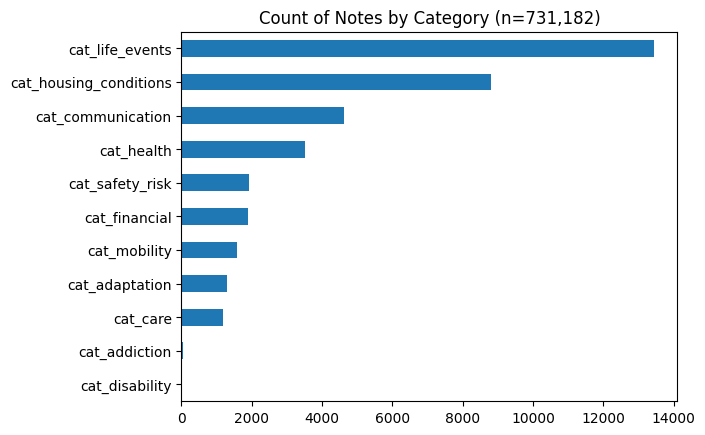

In [8]:
label_freqs.plot.barh(title='Count of Notes by Category (n=731,182)')

In [9]:
def calculate_ml_imbalance_metrics(df):
    """
    Calculates IRLbl, MeanIR, MaxIR, and CVIR for multi-label data.
    """
    # 1. Calculate IRLbl (Imbalance Ratio per Label)
    # Ratio between the majority label frequency and each label's frequency
    max_freq = df.max()
    irlbl = max_freq / df
    
    #23. MeanIR (Mean Imbalance Ratio)
    meanir = irlbl.mean()
    
    # 3. MaxIR (Maximum Imbalance Ratio)
    maxir = irlbl.max()
    
    # 5. CVIR (Coefficient of Variation of IRLbl)
    # Measures the variation/similarity of imbalance levels across labels
    cvir = irlbl.std() / irlbl.mean()
    
    return {
        "IRLbl": irlbl,
        "MeanIR": meanir,
        "MaxIR": maxir,
        "CVIR": cvir
    }

metrics = calculate_ml_imbalance_metrics(label_freqs)

print(f"IRLbl: {metrics['IRLbl'].values}")
print(f"MeanIR: {metrics['MeanIR']:.2f}")
print(f"MaxIR: {metrics['MaxIR']:.2f}")
print(f"CVIR: {metrics['CVIR']:.2f}")

IRLbl: [790.11764706 279.83333333  11.32546374  10.34822804   8.43188952
   7.06203996   6.95598136   3.81590909   2.90673014   1.52549688
   1.        ]
MeanIR: 102.12
MaxIR: 790.12
CVIR: 2.38


## Find acronyms


In [ ]:
import nltk
from collections import Counter

# Download the english dictionary (only needs to be run once)
nltk.download('words')
from nltk.corpus import words

# Load the standard English vocabulary into a fast-lookup set
english_vocab = set(word.lower() for word in words.words())

# 1. Combine all notes into one giant string, lowercase it
all_text = " ".join(df['note_content'].dropna().str.lower())

# 2. Extract all 2-to-4 letter words
short_words = re.findall(r'\b[a-z]{2,4}\b', all_text)

# 3. DICTIONARY SUBTRACTION: Only keep words NOT in the English dictionary
# (We also filter out 'url' since you already caught it!)
jargon_only = [word for word in short_words if word not in english_vocab]

# 4. Look at the top 100 most common jargon words
top_jargon = Counter(jargon_only).most_common(100)

top_jargon

[nltk_data] Downloading package words to /Users/arawat/nltk_data...
[nltk_data]   Package words is already up-to-date!


In [ ]:
normalization_dict = {
    # Hackney terms
    r'\bhsc\b': 'hackney service centre',
    r'\bmmh\b': 'Manage My Home',
    r'\blbh\b': 'London Borough of Hackney',
    r'\brcc\b': 'repairs contact centre',
    r'\buh\b': 'universal housing',
    # r'\buhw\b': 'universal housing ?',
    # r'\buht\b': 'universal housing ?',
    # r'\bncst\b': '??',

    # Housing terms
    r'\btnt\b': 'tenant',
    r'\btnts\b': 'tenants',
    r'\btmo\b': 'tenant management organisation',
    # r'\bdlo\b': 'direct labour organisation ??',
    r'\bnho\b': 'neighbourhood housing officer',
    r'\bahm\b': 'area housing manager',
    # r'\beo\b': 'estate officer',
    r'\bhb\b': 'housing benefit',
    r'\bnosp\b': 'notice of seeking possession',
    r'\bntq\b': 'notice to quit',
    r'\brtb\b': 'right to buy',
    r'\buc\b': 'universal credit',
    r'\basb\b': 'anti-social behaviour',
    # r'\bmpa\b': 'multiple ??',
    # r'\bctax\b': 'council tax',
    r'\bdv\b': 'domestic violence',

    # General terms
    r'\btel\b': 'telephone',
    r'\bdocs\b': 'documents',
    r'\bappt\b': 'appointment',
    r'\bacct\b': 'account',
    r'\bbacs\b': 'bank transfer',
    r'\binfo\b': 'information',
    r'\borg\b': 'organisation',
    r'\bsms\b': 'text message',
    r'\bmsg\b': 'message',
    r'\bcctv\b': 'camera',
    r'\bgp\b': 'general practitioner',
    r'\bpls\b': 'please',
    r'\brecd\b': 'received',
    r'\basap\b': 'as soon as possible',
    r'\bpls\b': 'please',
    r'\bcert\b': 'certificate',
    # r'\bo/s\b': 'outstanding',
    # r'\btc\b': 'telephone call',
    # r'\blm\b': 'left message',
    # r'\bvm\b': 'voicemail',
}

## Sample data (n=2000)
ML-RUS (Random Undersampling)

In [ ]:
sampled_data = []

# Get all from lowest categories  (disability, addiction - 17 + 48 = 65)
sampled_data.append(df[df['cat_disability'] == True])
sampled_data.append(df[df['cat_addiction'] == True])

# Grab 150 each from the remaining categories (150 * 9 = 1350)
categories_to_sample = [
    'cat_safety_risk', 'cat_mobility', 'cat_life_events', 
    'cat_housing_conditions', 'cat_health', 'cat_financial', 
    'cat_communication', 'cat_care', 'cat_adaptation'
]
for cat in categories_to_sample:
    cat_sample = df[df[cat] == True].sample(n=150, random_state=RANDOM_STATE)
    sampled_data.append(cat_sample)

# Grab remaining from unflagged to reach 2000 total (2000 - 1350 - 65 = 585)
unflagged_records_sample = df[df['unflagged'] == True].sample(n=600, random_state=RANDOM_STATE)
sampled_data.append(unflagged_records_sample)

# Combine & drop duplicates
final_sample = pd.concat(sampled_data)
final_sample = final_sample.drop_duplicates(subset=['note_id'])

del df
final_sample

,note_id,note_content,note_category,cat_safety_risk,cat_mobility,cat_life_events,cat_housing_conditions,cat_health,cat_financial,cat_disability,cat_communication,cat_care,cat_addiction,cat_adaptation,unflagged
16028,351b501f-f877-7b51-1b07-f065d07f0147,[Category: Tenure management] Call Summary; Ca...,Tenure management,False,False,False,False,False,False,True,False,False,False,False,False
31465,0cf1dcef-63cd-4a0f-bb84-6f316de60a5c,[Category: Tenure management] ADDITIONAL NOTE ...,Tenure management,False,False,False,False,False,False,True,False,False,False,False,False
51881,f96a9bbe-4d1c-2efa-c2e4-1e3551f80fee,[Category: Tenure management] Dear Marcia\n\nD...,Tenure management,False,False,False,False,False,False,True,False,True,False,False,False
134837,4e5a965a-0e88-490a-807e-ffb2adc0f69e,[Category: estateManagement] PSED Consideratio...,estateManagement,False,False,False,False,False,False,True,False,False,False,False,False
136128,b0ba31aa-8484-415c-9f5b-20c9bd1be3c2,[Category: tenureManagement] reply from tnt re...,tenureManagement,False,False,False,True,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48078,a012334e-1f6b-aa75-d9cc-ed030b213605,[Category: Tenure management] Direct Offer: As...,Tenure management,False,False,False,False,False,False,False,False,False,False,False,True
483956,64cae06b-cb3f-413c-bc12-7f7154827bf3,[Category: tenureManagement] New Let Introduct...,tenureManagement,False,False,False,False,False,False,False,False,False,False,False,True
605747,5799fc21-7da7-3c99-948e-f71636c24c46,[Category: Tenancy Management] Call Summary; C...,Tenancy Management,False,False,False,False,False,False,False,False,False,False,False,True
243544,c029e611-2749-061d-7330-584b7cd4eac4,[Category: Tenancy Management] Client has reci...,Tenancy Management,False,False,False,False,False,False,False,False,False,False,False,True


<Axes: title={'center': 'Count of Notes by Category (Sample, n=2000)'}>

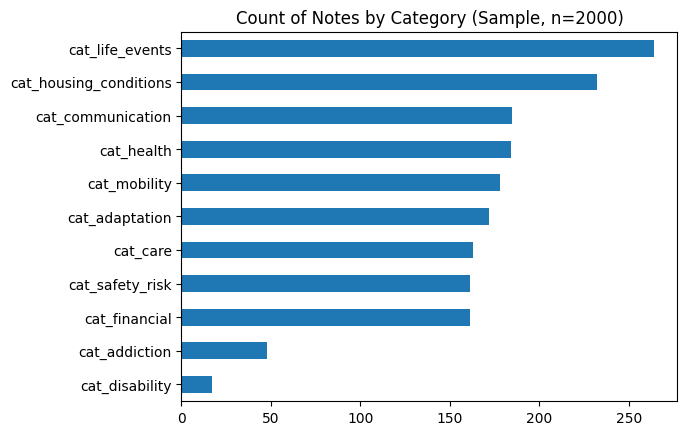

In [ ]:
final_sample[category_regex_dict.keys()].sum(axis=0).sort_values(ascending=True).plot.barh(title='Count of Notes by Category (Sample, n=2000)')

## Replace acronyms

In [ ]:
for pattern, replacement in normalization_dict.items():
    final_sample['note_content'] = final_sample['note_content'].str.replace(
        pattern, 
        replacement, 
        case=False, 
        regex=True
    )
final_sample

,note_id,note_content,note_category,cat_safety_risk,cat_mobility,cat_life_events,cat_housing_conditions,cat_health,cat_financial,cat_disability,cat_communication,cat_care,cat_addiction,cat_adaptation,unflagged
16028,351b501f-f877-7b51-1b07-f065d07f0147,[Category: Tenure management] Call Summary; Ca...,Tenure management,False,False,False,False,False,False,True,False,False,False,False,False
31465,0cf1dcef-63cd-4a0f-bb84-6f316de60a5c,[Category: Tenure management] ADDITIONAL NOTE ...,Tenure management,False,False,False,False,False,False,True,False,False,False,False,False
51881,f96a9bbe-4d1c-2efa-c2e4-1e3551f80fee,[Category: Tenure management] Dear Marcia\n\nD...,Tenure management,False,False,False,False,False,False,True,False,True,False,False,False
134837,4e5a965a-0e88-490a-807e-ffb2adc0f69e,[Category: estateManagement] PSED Consideratio...,estateManagement,False,False,False,False,False,False,True,False,False,False,False,False
136128,b0ba31aa-8484-415c-9f5b-20c9bd1be3c2,[Category: tenureManagement] reply from tenant...,tenureManagement,False,False,False,True,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48078,a012334e-1f6b-aa75-d9cc-ed030b213605,[Category: Tenure management] Direct Offer: As...,Tenure management,False,False,False,False,False,False,False,False,False,False,False,True
483956,64cae06b-cb3f-413c-bc12-7f7154827bf3,[Category: tenureManagement] New Let Introduct...,tenureManagement,False,False,False,False,False,False,False,False,False,False,False,True
605747,5799fc21-7da7-3c99-948e-f71636c24c46,[Category: Tenancy Management] Call Summary; C...,Tenancy Management,False,False,False,False,False,False,False,False,False,False,False,True
243544,c029e611-2749-061d-7330-584b7cd4eac4,[Category: Tenancy Management] Client has reci...,Tenancy Management,False,False,False,False,False,False,False,False,False,False,False,True


## PII Redaction

In [ ]:
from presidio_analyzer import AnalyzerEngine, BatchAnalyzerEngine
from presidio_anonymizer import BatchAnonymizerEngine
from presidio_anonymizer.entities import OperatorConfig

from faker import Faker

In [ ]:
# Set up engines
fake = Faker('en-GB')
analyzer = AnalyzerEngine()
batch_analyzer = BatchAnalyzerEngine(analyzer_engine=analyzer)
batch_anonymizer = BatchAnonymizerEngine()

# Replace names with fake names
def fake_name(x):
    return fake.name()
operators = {
    "PERSON": OperatorConfig("custom", {"lambda": fake_name})
}


In [ ]:
# content column to dict (presidio expects dictionary)
text_dict = {"note_content": final_sample['note_content'].tolist()}


In [ ]:
# Analyze (Find Entities)
analyzer_results = batch_analyzer.analyze_dict(text_dict, language="en")

In [ ]:
# Anonymise (replace names with fake, other PII with tags)
anonymizer_results = batch_anonymizer.anonymize_dict(
    analyzer_results, 
    operators=operators
)

In [ ]:
# Combine back into df with the original columns

scrubbed_text_series = pd.Series(anonymizer_results['note_content'], name='note_content')
scrubbed_df = final_sample.drop(columns=['note_content']).join(scrubbed_text_series)

scrubbed_df

,note_id,note_content,cat_safety_risk,cat_mobility,cat_life_events,cat_housing_conditions,cat_health,cat_financial,cat_disability,cat_communication,cat_care,cat_addiction,cat_adaptation,unflagged
0,351b501f-<US_DRIVER_LICENSE>-7b51-1b07-f065d07...,[Category: Tenure management] Call Summary; Ca...,False,False,False,False,False,False,True,False,False,False,False,False
1,0cf1dcef-63cd-4a0f-bb84-6f316de60a5c,[Category: Tenure management] ADDITIONAL NOTE ...,False,False,False,False,False,False,True,False,False,False,False,False
2,f96a9bbe-4d1c-2efa-c2e4-1e3551f80fee,[Category: Tenure management] Dear Marcia\n\nD...,False,False,False,False,False,False,True,False,True,False,False,False
3,4e5a965a-0e88-490a-807e-ffb2adc0f69e,[Category: estateManagement] PSED Consideratio...,False,False,False,False,False,False,True,False,False,False,False,False
4,b0ba31aa-8484-415c-9f5b-20c9bd1be3c2,[Category: tenureManagement] reply from tenant...,False,False,False,True,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996,a012334e-1f6b-aa75-d9cc-ed030b213605,[Category: Tenure management] Direct Offer: As...,False,False,False,False,False,False,False,False,False,False,False,True
1997,64cae06b-cb3f-413c-bc12-7f7154827bf3,[Category: tenureManagement] New Let Introduct...,False,False,False,False,False,False,False,False,False,False,False,True
1998,5799fc21-7da7-3c99-948e-f71636c24c46,[Category: Tenancy Management] Call Summary; C...,False,False,False,False,False,False,False,False,False,False,False,True
1999,c029e611-2749-061d-7330-584b7cd4eac4,[Category: Tenancy Management] Client has reci...,False,False,False,False,False,False,False,False,False,False,False,True


## Export

### CSV

In [ ]:
scrubbed_df.to_csv('data/output/balanced_sample.csv', index=False)

### Build JSON (label studio)

In [ ]:
import json

entity_regex_dict = {
    "Pronoun": r"(?i)\b(he|him|his|she|her|hers|they|them|their)\b", # standard pronouns
    "Descriptive Role": r"(?i)\b(tenant|tenants|leaseholder|leaseholders|resident|residents|child|children|son|daughter|partner|wife|husband|mother|father|caller|applicant)\b" # common housing roles
}

label_mapping = {
    "cat_safety_risk": "Safety & Risk",
    "cat_mobility": "Mobility",
    "cat_life_events": "Life Events",
    "cat_housing_conditions": "Housing Conditions",
    "cat_health": "Health",
    "cat_financial": "Financial",
    "cat_disability": "Disability (Sensory)",
    "cat_communication": "Communication Needs",
    "cat_care": "Care",
    "cat_addiction": "Addiction",
    "cat_adaptation": "Adaptation"
}

label_studio_tasks = []

for index, row in scrubbed_df.iterrows():
    # Loop through each row and build the JSON structure
    text = str(row['note_content'])
    note_id = str(row['note_id'])
    identified_labels = []
    
    # --- pre-annotate additional needs tags  ---
    for cat_key, regex_pattern in category_regex_dict.items():
        if row.get(cat_key) == False:
            continue  # Skip if athena didn't flag this category for the note
        label_name = label_mapping[cat_key]
        for match in re.finditer(regex_pattern, text):  # finditer finds the specific chars where the regex matches
            identified_labels.append({
                "from_name": "need_labels", # Points to the AN labels
                "to_name": "text",
                "type": "labels",
                "value": {
                    "start": match.start(),
                    "end": match.end(),
                    "text": match.group(),
                    "labels": [label_name]
                } # Highlighting specific span
            })
                
    # --- pre-annotate entities ---
    for entity_label, regex_pattern in entity_regex_dict.items():
        for match in re.finditer(regex_pattern, text):
            identified_labels.append({
                "from_name": "entity_labels", # Points to the entity labels
                "to_name": "text",
                "type": "labels",
                "value": {
                    "start": match.start(),
                    "end": match.end(),
                    "text": match.group(),
                    "labels": [entity_label]
                } # Highlighting specific span
            })
    
    # Construct the final JSON payload (label studio structure - docs)
    task = {
        "data": {
            "note_content": text,
            "id": note_id
        },
        "predictions": [{
            "model_version": "pre_annotated",
            "score": 1.0,
            "result": identified_labels
        }]
    }
        
    label_studio_tasks.append(task)

In [ ]:
with open("data/output/label_studio_pre_annotated.json", "w") as f:
    json.dump(label_studio_tasks, f, indent=2)

len(label_studio_tasks)

2001